✅ Data Loaded Successfully!
Shape: (2216, 64)
    Education  Has_Partner  Income  Recency  Wines  Fruits  Meat  Fish  \
0  Graduation            0   58138       58    635      88   546   172   
1  Graduation            0   46344       38     11       1     6     2   
2  Graduation            1   71613       26    426      49   127   111   

   Sweets  Gold  ...  R_score  F_score  M_score  RFM_Total  log_Income  \
0      88    88  ...      3.0      3.0      5.0       11.0   10.970592   
1       1     6  ...      4.0      3.0      1.0        8.0   10.743869   
2      21    42  ...      4.0      4.0      4.0       12.0   11.179046   

   log_Total_Spent  Income_x_HasPartner  Age_x_WebShare  Age_Bin  Income_q  
0         7.388946                    0       20.727273    45-59         2  
1         3.332205                    0       15.000000      60+         2  
2         6.655440                71613       19.600000    45-59         3  

[3 rows x 64 columns]

Categorical Columns: ['Educa

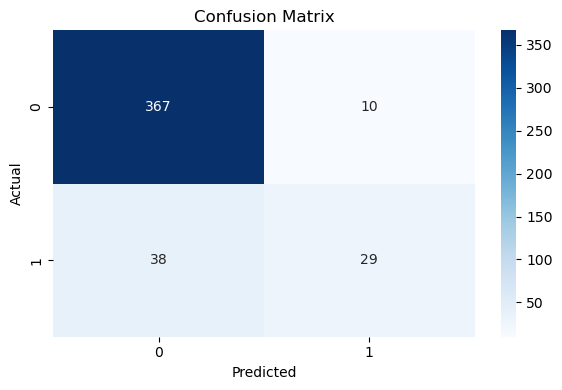

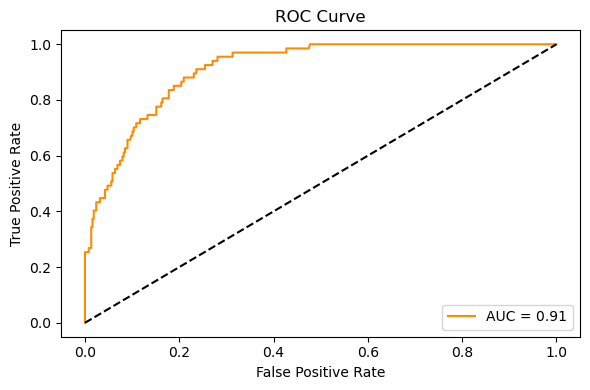

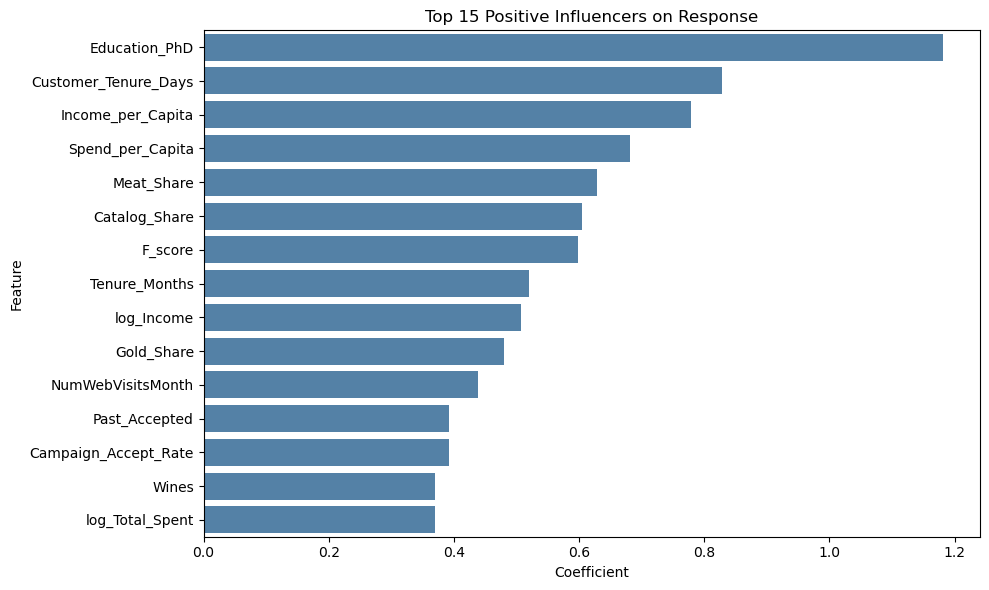

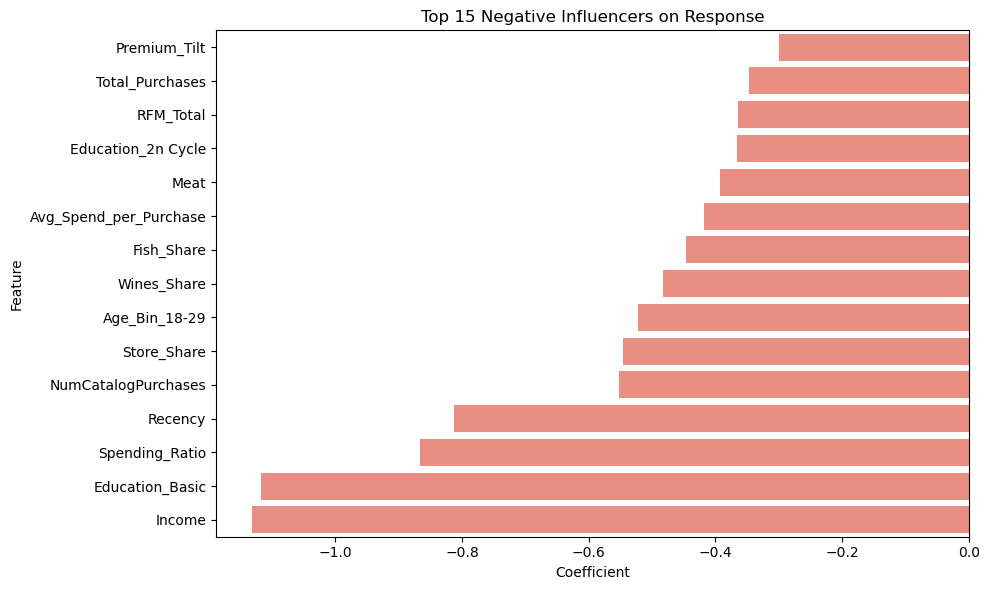


💾 Model saved to results_lr/logistic_regression_model.pkl
📈 Metrics saved to results_lr/metrics.txt

🔍 CRISP-DM Summary
1️⃣ Business Understanding → Predict customer campaign response.
2️⃣ Data Understanding → Includes socio-demographics & spending behavior.
3️⃣ Data Preparation → Missing values imputed, scaled, and encoded.
4️⃣ Modeling → Logistic Regression baseline.
5️⃣ Evaluation → Accuracy = 0.8919, AUC = 0.9120
6️⃣ Deployment → Model & results saved in /results_lr folder.


In [21]:
#Logistic Regression → baseline linear model
#Random Forest → nonlinear, ensemble model
# ================================================================
# LOGISTIC REGRESSION BASELINE MODEL (with Imputation + Saving)
# Dataset: customers_featured.csv
# Goal: Predict "Response" based on customer personality & RFM features
# Methodology: CRISP-DM
# ================================================================

# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_curve,
    auc
)
import warnings
warnings.filterwarnings('ignore')

# -----------------------------
# 2. LOAD & UNDERSTAND DATA
# -----------------------------
df = pd.read_csv("customers_featured.csv")

print("✅ Data Loaded Successfully!")
print(f"Shape: {df.shape}")
print(df.head(3))

# Handle missing values in target (if any)
df = df.dropna(subset=["Response"])

# Convert Response to binary if needed
if df["Response"].dtype == "object":
    df["Response"] = df["Response"].map({"Yes": 1, "No": 0})

# Drop ID-like columns
df = df.loc[:, ~df.columns.str.contains('ID', case=False)]

# Separate features/target
X = df.drop("Response", axis=1)
y = df["Response"]

# Identify categorical/numerical columns
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f"\nCategorical Columns: {categorical_cols}")
print(f"Numerical Columns: {numerical_cols}")

# -----------------------------
# 3. DATA PREPROCESSING PIPELINE
# -----------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# -----------------------------
# 4. TRAIN-TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTraining Samples: {X_train.shape[0]}")
print(f"Testing Samples: {X_test.shape[0]}")

# -----------------------------
# 5. MODELING
# -----------------------------
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

model.fit(X_train, y_train)
print("\n✅ Model training complete!")

# -----------------------------
# 6. EVALUATION
# -----------------------------
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy: {accuracy:.4f}")

# -----------------------------
# 7. VISUALIZATIONS (Save to results_lr/)
# -----------------------------
os.makedirs("results_lr", exist_ok=True)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("results_lr/confusion_matrix.png", dpi=300)
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color="darkorange")
plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("results_lr/roc_curve.png", dpi=300)
plt.show()

# -----------------------------
# 8. FEATURE IMPORTANCE
# -----------------------------
# Extract feature names
feature_names = (
    numerical_cols +
    list(model.named_steps["preprocessor"]
         .named_transformers_["cat"]
         .named_steps["encoder"]
         .get_feature_names_out(categorical_cols))
)

# Extract coefficients
coefficients = model.named_steps["classifier"].coef_[0]
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
}).sort_values("Coefficient", ascending=False)

# Save feature importance CSV
importance_df.to_csv("results_lr/feature_importance.csv", index=False)

# Plot top features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x="Coefficient", y="Feature", color="steelblue")
plt.title("Top 15 Positive Influencers on Response")
plt.tight_layout()
plt.savefig("results_lr/top_positive_features.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.tail(15), x="Coefficient", y="Feature", color="salmon")
plt.title("Top 15 Negative Influencers on Response")
plt.tight_layout()
plt.savefig("results_lr/top_negative_features.png", dpi=300)
plt.show()

# -----------------------------
# 9. SAVE MODEL & METRICS
# -----------------------------
joblib.dump(model, "results_lr/logistic_regression_model.pkl")
print("\n💾 Model saved to results_lr/logistic_regression_model.pkl")

# Save metrics
with open("results_lr/metrics.txt", "w") as f:
    f.write(f"Accuracy: {accuracy:.4f}\n")
    f.write(f"AUC: {roc_auc:.4f}\n")
print("📈 Metrics saved to results_lr/metrics.txt")

# -----------------------------
# 10. CRISP-DM SUMMARY
# -----------------------------
print("\n🔍 CRISP-DM Summary")
print("1️⃣ Business Understanding → Predict customer campaign response.")
print("2️⃣ Data Understanding → Includes socio-demographics & spending behavior.")
print("3️⃣ Data Preparation → Missing values imputed, scaled, and encoded.")
print("4️⃣ Modeling → Logistic Regression baseline.")
print(f"5️⃣ Evaluation → Accuracy = {accuracy:.4f}, AUC = {roc_auc:.4f}")
print("6️⃣ Deployment → Model & results saved in /results_lr folder.")


✅ Data Loaded Successfully!
Shape: (2216, 64)
    Education  Has_Partner  Income  Recency  Wines  Fruits  Meat  Fish  \
0  Graduation            0   58138       58    635      88   546   172   
1  Graduation            0   46344       38     11       1     6     2   
2  Graduation            1   71613       26    426      49   127   111   

   Sweets  Gold  ...  R_score  F_score  M_score  RFM_Total  log_Income  \
0      88    88  ...      3.0      3.0      5.0       11.0   10.970592   
1       1     6  ...      4.0      3.0      1.0        8.0   10.743869   
2      21    42  ...      4.0      4.0      4.0       12.0   11.179046   

   log_Total_Spent  Income_x_HasPartner  Age_x_WebShare  Age_Bin  Income_q  
0         7.388946                    0       20.727273    45-59         2  
1         3.332205                    0       15.000000      60+         2  
2         6.655440                71613       19.600000    45-59         3  

[3 rows x 64 columns]

Categorical Columns: ['Educa

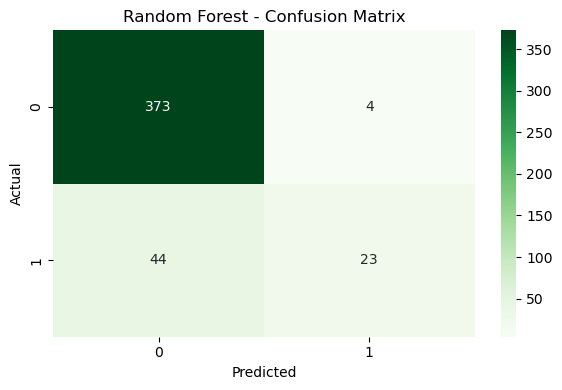

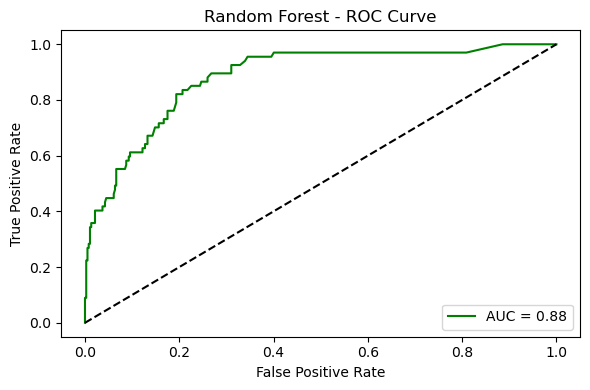

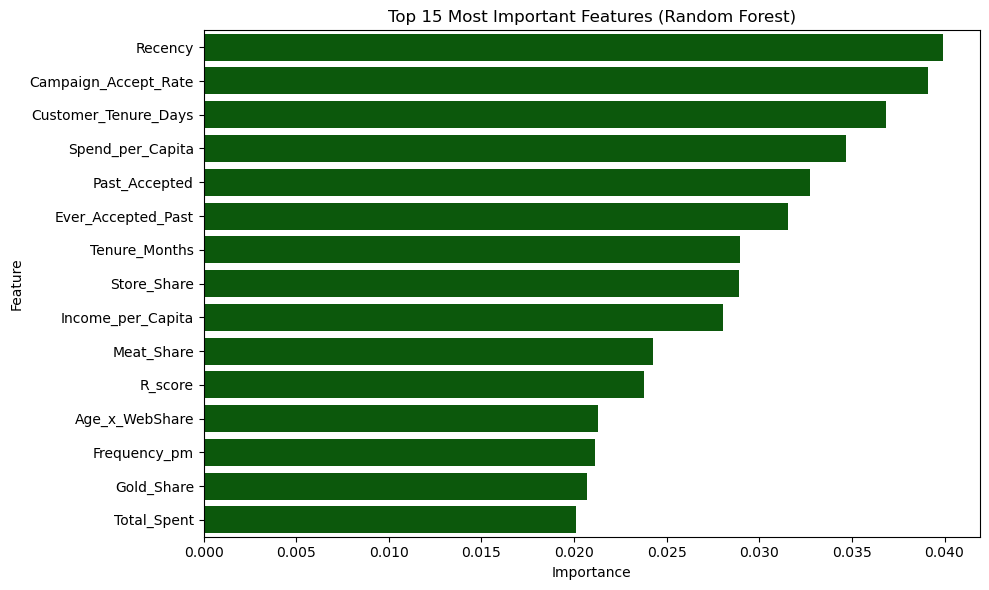


💾 Model saved to results_rf/random_forest_model.pkl
📈 Metrics saved to results_rf/metrics.txt

🔍 CRISP-DM Summary
1️⃣ Business Understanding → Predict customer campaign response.
2️⃣ Data Understanding → Personality and RFM features analyzed.
3️⃣ Data Preparation → Missing values imputed, features scaled and encoded.
4️⃣ Modeling → Random Forest Classifier (200 trees).
5️⃣ Evaluation → Accuracy = 0.8919, AUC = 0.8815
6️⃣ Deployment → Model & results saved in /results_rf folder.
7️⃣ Next Step → Compare with Logistic Regression to measure model uplift.


In [ ]:
# ================================================================
# RANDOM FOREST CLASSIFIER MODEL (CRISP-DM)
# Dataset: customers_featured.csv
# Goal: Predict "Response" column based on customer features
# ================================================================

# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_curve,
    auc
)
import warnings
warnings.filterwarnings('ignore')

# -----------------------------
# 2. LOAD & UNDERSTAND DATA
# -----------------------------
df = pd.read_csv("customers_featured.csv")

print("✅ Data Loaded Successfully!")
print(f"Shape: {df.shape}")
print(df.head(3))

# Handle missing values in target (if any)
df = df.dropna(subset=["Response"])

# Convert Response to binary if needed
if df["Response"].dtype == "object":
    df["Response"] = df["Response"].map({"Yes": 1, "No": 0})

# Drop ID-like columns
df = df.loc[:, ~df.columns.str.contains('ID', case=False)]

# Separate features/target
X = df.drop("Response", axis=1)
y = df["Response"]

# Identify categorical/numerical columns
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f"\nCategorical Columns: {categorical_cols}")
print(f"Numerical Columns: {numerical_cols}")

# -----------------------------
# 3. DATA PREPROCESSING PIPELINE
# -----------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# -----------------------------
# 4. TRAIN-TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTraining Samples: {X_train.shape[0]}")
print(f"Testing Samples: {X_test.shape[0]}")

# -----------------------------
# 5. MODELING
# -----------------------------
# Random Forest Classifier
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
print("\n✅ Random Forest training complete!")

# -----------------------------
# 6. EVALUATION
# -----------------------------
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy: {accuracy:.4f}")

# -----------------------------
# 7. VISUALIZATIONS (Save to results/)
# -----------------------------
os.makedirs("results_rf", exist_ok=True)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("results_rf/confusion_matrix.png", dpi=300)
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color="green")
plt.plot([0, 1], [0, 1], "k--")
plt.title("Random Forest - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("results_rf/roc_curve.png", dpi=300)
plt.show()

# -----------------------------
# 8. FEATURE IMPORTANCE
# -----------------------------
# Extract feature names (after preprocessing)
feature_names = (
    numerical_cols +
    list(rf_model.named_steps["preprocessor"]
         .named_transformers_["cat"]
         .named_steps["encoder"]
         .get_feature_names_out(categorical_cols))
)

# Extract importances
importances = rf_model.named_steps["classifier"].feature_importances_
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

# Save feature importance CSV
importance_df.to_csv("results_rf/feature_importance.csv", index=False)

# Plot top features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x="Importance", y="Feature", color="darkgreen")
plt.title("Top 15 Most Important Features (Random Forest)")
plt.tight_layout()
plt.savefig("results_rf/top_features.png", dpi=300)
plt.show()

# -----------------------------
# 9. SAVE MODEL & METRICS
# -----------------------------
joblib.dump(rf_model, "results_rf/random_forest_model.pkl")
print("\n💾 Model saved to results_rf/random_forest_model.pkl")

# Save metrics
with open("results_rf/metrics.txt", "w") as f:
    f.write(f"Accuracy: {accuracy:.4f}\n")
    f.write(f"AUC: {roc_auc:.4f}\n")
print("📈 Metrics saved to results_rf/metrics.txt")

# -----------------------------
# 10. CRISP-DM SUMMARY
# -----------------------------
print("\n🔍 CRISP-DM Summary")
print("1️⃣ Business Understanding → Predict customer campaign response.")
print("2️⃣ Data Understanding → Personality and RFM features analyzed.")
print("3️⃣ Data Preparation → Missing values imputed, features scaled and encoded.")
print("4️⃣ Modeling → Random Forest Classifier (200 trees).")
print(f"5️⃣ Evaluation → Accuracy = {accuracy:.4f}, AUC = {roc_auc:.4f}")
print("6️⃣ Deployment → Model & results saved in /results_rf folder.")
print("7️⃣ Next Step → Compare with Logistic Regression to measure model uplift.")
